# Notebook mémoire




## 1. Mise en place de l'environnement de travail



In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!unzip /content/drive/MyDrive/M1S2_ADT/lexploreur.zip -d /content/

import pandas as pd


Mounted at /content/drive
Archive:  /content/drive/MyDrive/M1S2_ADT/lexploreur.zip
   creating: /content/lexploreur/
  inflating: /content/lexploreur/utils.py  
  inflating: /content/lexploreur/description.py  
  inflating: /content/lexploreur/__init__.py  
  inflating: /content/lexploreur/stats.py  
  inflating: /content/lexploreur/tm.py  
  inflating: /content/lexploreur/corpus.py  
   creating: /content/lexploreur/__pycache__/
  inflating: /content/lexploreur/__pycache__/__init__.cpython-312.pyc  
  inflating: /content/lexploreur/__pycache__/description.cpython-312.pyc  
  inflating: /content/lexploreur/__pycache__/utils.cpython-312.pyc  
  inflating: /content/lexploreur/__pycache__/corpus.cpython-312.pyc  
  inflating: /content/lexploreur/__pycache__/tm.cpython-312.pyc  
  inflating: /content/lexploreur/__pycache__/stats.cpython-312.pyc  


### Chargement de lexploreur




In [ ]:
from lexploreur.corpus import *
from lexploreur.utils import *


Le paquet lexploreur est chargé !


/content/lexploreur/corpus.py:53: SyntaxWarning: invalid escape sequence '\ '
  print(f"/!\ Le texte de la ligne {index}: est NaN.")


## 2. Import des données et création de sous-corpus




In [ ]:
df = pd.read_csv("/content/drive/MyDrive/corpus_articles_csv.csv", sep=";")


df


,id,date,journal,title,author,content
0,1,2015-08-26,20Minutessiteweb,NaN,NaN,Après les trésors du musée de Mossoul (Irak) e...
1,2,2015-06-29,20Minutessiteweb,NaN,NaN,Le mythique site américain d'Alamo ou les cave...
2,3,2015-05-26,24HeuresSuisse,NaN,NaN,Andrés Allemand Irina Bokova est catastrophé...
3,7,2015-03-07,AFPDoc,NaN,NaN,Samarra (Irak) (AFP) - L'ONU a dénoncé samedi ...
4,6,2013-06-23,AFPDoc,NaN,NaN,Phnom Penh (AFP) - L'Unesco clôturait dimanche...
...,...,...,...,...,...,...
437,438,2013-08-03,Téléramano,NaN,NaN,La pierre de grès rouge éclate sous les talons...
438,439,2014-07-05,Téléramano,NaN,NaN,Où en est l'archéologie en Irak ?Le site de Ni...
439,440,2015-05-26,TribunedeGenève,NaN,NaN,Irina Bokova est catastrophée. « Pillages et d...
440,441,2015-10-15,ValeursActuelles,NaN,NaN,Les bouddhas de BamiyanPerchée à 2 500 mètres ...


In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['year_month'] = df['date'].dt.to_period('M').astype(str)


## 3. NER



In [ ]:
import spacy

spacy.cli.download('fr_core_news_lg')

df['date'] = df['date'].astype(str)

corpus(df, corpus_name="corpus_article_ner.json",
       text_column="content",
       spacy_model="fr_core_news_lg",
       ner=True)



✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Le texte de la ligne 0. est en cours de traitement...
Le texte de la ligne 1. est en cours de traitement...
Le texte de la ligne 2. est en cours de traitement...
Le texte de la ligne 3. est en cours de traitement...
Le texte de la ligne 4. est en cours de traitement...
Le texte de la ligne 5. est en cours de traitement...
Le texte de la ligne 6. est en cours de traitement...
Le texte de la ligne 7. est en cours de traitement...
Le texte de la ligne 8. est en cours de traitement...
Le texte de la ligne 9. est en cours de traitement...
Le texte de la ligne 10. est en cours de traitement...
Le texte de la ligne 11. est en cours de traitement...
Le texte de l

## 4. Création des vues lexicales



In [ ]:
df_sw = pd.read_csv('/content/drive/MyDrive/M1S2_ADT/stopwords_fr.csv')
stopwords = df_sw["lemme"].to_list()

additional_stopwords = ["unesco", "patrimoine", "conservation", "archeologique", "historique", "monument", "tourisme"]
stopwords.extend(additional_stopwords)


### Vue lexicale pour la description du corpus (tokens)




In [ ]:
df_lexical_view_desc = lexical_view('corpus_article_ner.json',
                               feature_to_extract="token",
                               lowercase=True)


### Vue lexicale POS (pour la section Entités nommées)


In [ ]:
df_lexical_view = lexical_view('corpus_article_ner.json',
                               feature_to_extract="pos")

df_lexical_view


,pos
0,"[ADP, DET, NOUN, ADP, NOUN, ADP, LOC, PUNCT, L..."
1,"[DET, ADJ, NOUN, ADJ, ADP, LOC, CCONJ, DET, NO..."
2,"[PER, SPACE, PER, AUX, VERB, PUNCT, PUNCT, NOU..."
3,"[LOC, PUNCT, LOC, PUNCT, PUNCT, ORG, PUNCT, PU..."
4,"[LOC, PUNCT, ORG, PUNCT, PUNCT, DET, ORG, VERB..."
...,...
437,"[DET, NOUN, ADP, NOUN, ADJ, VERB, ADP, DET, NO..."
438,"[PRON, PRON, AUX, DET, NOUN, ADP, LOC, PUNCT, ..."
439,"[PER, AUX, VERB, PUNCT, PUNCT, NOUN, CCONJ, NO..."
440,"[DET, NOUN, ADP, LOC, ADP, DET, DET, NOUN, ADP..."


### Vue lexicale lemmatisée pour le topic modeling — Corpus 1



In [ ]:
df_lexical_view_topic = lexical_view('corpus_article_ner.json',
                               feature_to_extract="lemma",
                               stopwords=stopwords,
                               lowercase=True,
                               exclude_pos=["PUNCT", "SPACE", "SYM", "NUM", "AUX", "X", ])


## 6. Description du corpus




In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_desc = CountVectorizer(tokenizer=nothing, preprocessor=nothing, token_pattern=None)
X_desc = vectorizer_desc.fit_transform(df_lexical_view_desc['token'])

dtm_desc = pd.DataFrame(X_desc.toarray(), columns=vectorizer_desc.get_feature_names_out())


In [ ]:
from lexploreur.description import *

dico_desc = features_frequencies(dtm_desc)

corpus_size(dtm_desc)


Total d'occurrences : 452202
Total de formes : 30735


In [ ]:
dtm_desc


,\n,\n\n\n,\n,,,,!,"""","""a","""après",...,—,‘,’,•,"• , • l e t r u c d u j o u r",•mahadow,…,€,●,● missions de san antonio
0,1,0,1,0,10,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,1,0,17,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,14,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,19,0,0,28,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,14,0,0,12,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
437,1,0,0,0,8,0,4,4,0,0,...,0,0,0,0,0,0,0,0,0,0
438,1,0,0,1,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
439,1,0,0,0,12,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
440,1,0,0,4,12,0,2,7,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
nb_mots_article = dtm_desc.sum(axis=1)
moyenne_mots_article = nb_mots_article.mean()

moyenne_mots_article


np.float64(1023.0814479638009)

### Nombre de mots par article et par année



In [ ]:
mots_par_article_desc = dtm_desc.sum(axis=1)

df['date'] = pd.to_datetime(df['date'])
average_date = df['date'].mean()
print(f"Date moyenne des articles : {average_date}")


Date moyenne des articles : 2010-09-18 08:02:10.316742144


In [ ]:
articles_word_counts_by_year = pd.DataFrame({
    'year': df['year'],
    'word_count_desc': mots_par_article_desc
})
display(articles_word_counts_by_year.head())


,year,word_count_desc
0,2015,694
1,2015,815
2,2015,1422
3,2015,844
4,2013,538


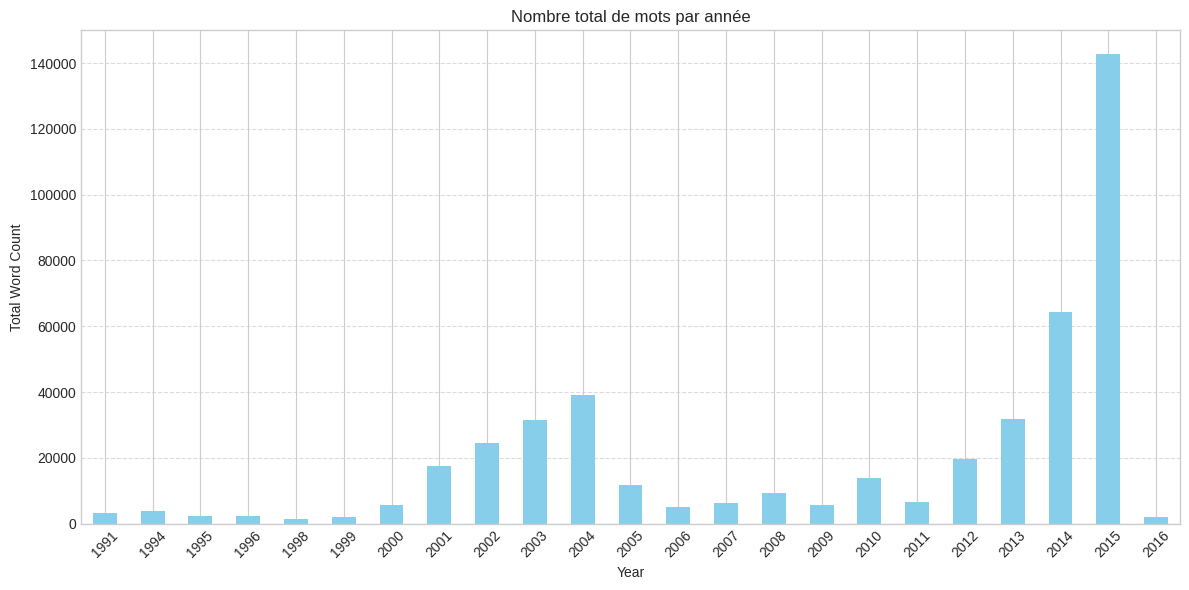

In [ ]:
import matplotlib.pyplot as plt

year_word_counts = articles_word_counts_by_year.groupby('year')['word_count_desc'].sum()

plt.figure(figsize=(12, 6))
year_word_counts.plot(kind='bar', color='skyblue')
plt.title('Nombre total de mots par année')
plt.xlabel('Year')
plt.ylabel('Total Word Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Nombre d'articles par année




In [ ]:
toutes_les_annees = range(1990, 2017)
articles_par_an = df.groupby('year').size().reindex(toutes_les_annees, fill_value=0)


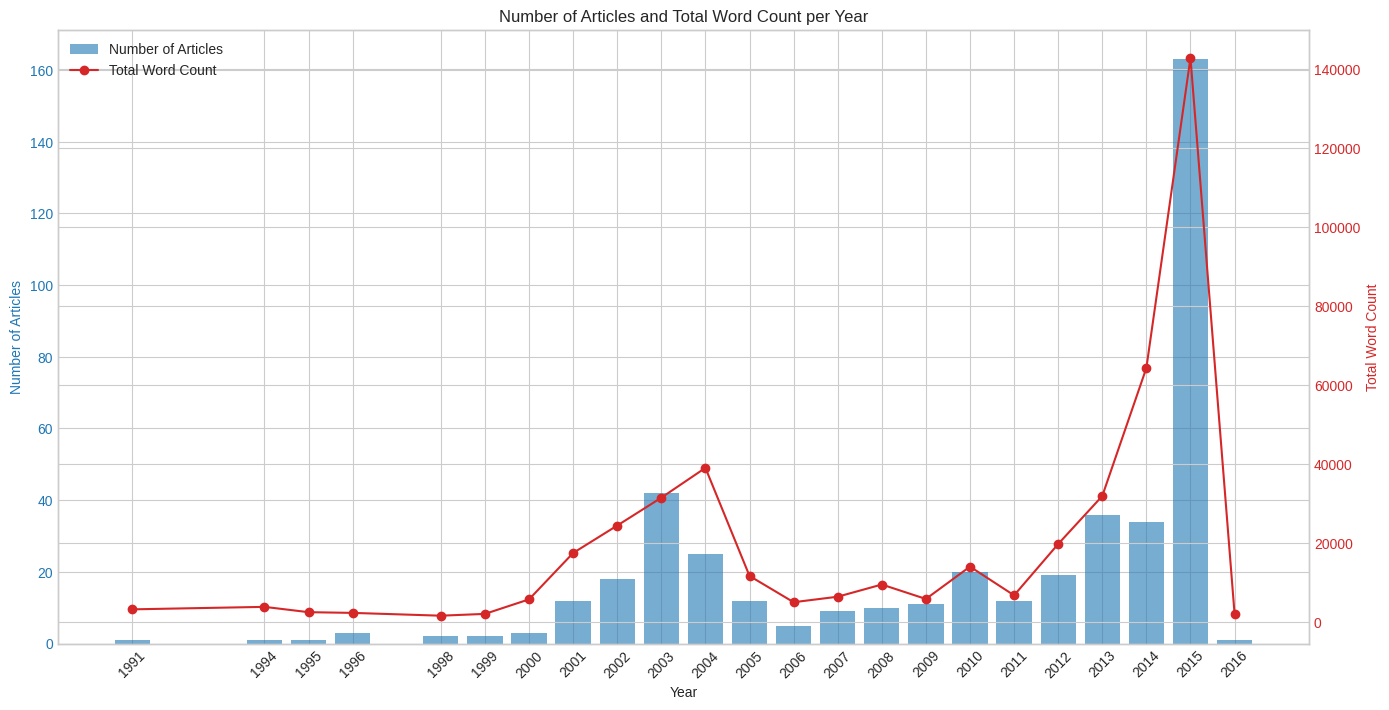

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

combined_df = pd.DataFrame({
    'Number of Articles': articles_par_an,
    'Total Word Count': year_word_counts
})

combined_df = combined_df.loc[(combined_df['Number of Articles'] > 0) | (combined_df['Total Word Count'] > 0)]

fig, ax1 = plt.subplots(figsize=(14, 7))

color = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Articles', color=color)
ax1.bar(combined_df.index, combined_df['Number of Articles'], color=color, alpha=0.6, label='Number of Articles')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(combined_df.index)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()

color = 'tab:red'
ax2.set_ylabel('Total Word Count', color=color)
ax2.plot(combined_df.index, combined_df['Total Word Count'], color=color, marker='o', label='Total Word Count')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Number of Articles and Total Word Count per Year')
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, loc='upper left')
plt.show()


### Répartition par journal


In [ ]:
articles_by_journal = df.groupby('journal').size().sort_values(ascending=False)

print("Nombre d'articles par journal:")
print(articles_by_journal.to_string())


Nombre d'articles par journal:
journal
LeMonde                                                                                                                     44
LeFigaro                                                                                                                    34
LaCroix                                                                                                                     33
AFPInfosMondiales                                                                                                           25
LeMondefr                                                                                                                   22
AFPInfosFrançaises                                                                                                          17
AFPJournalInternetAFPfrançais                                                                                               14
LeFigarofr                                                              

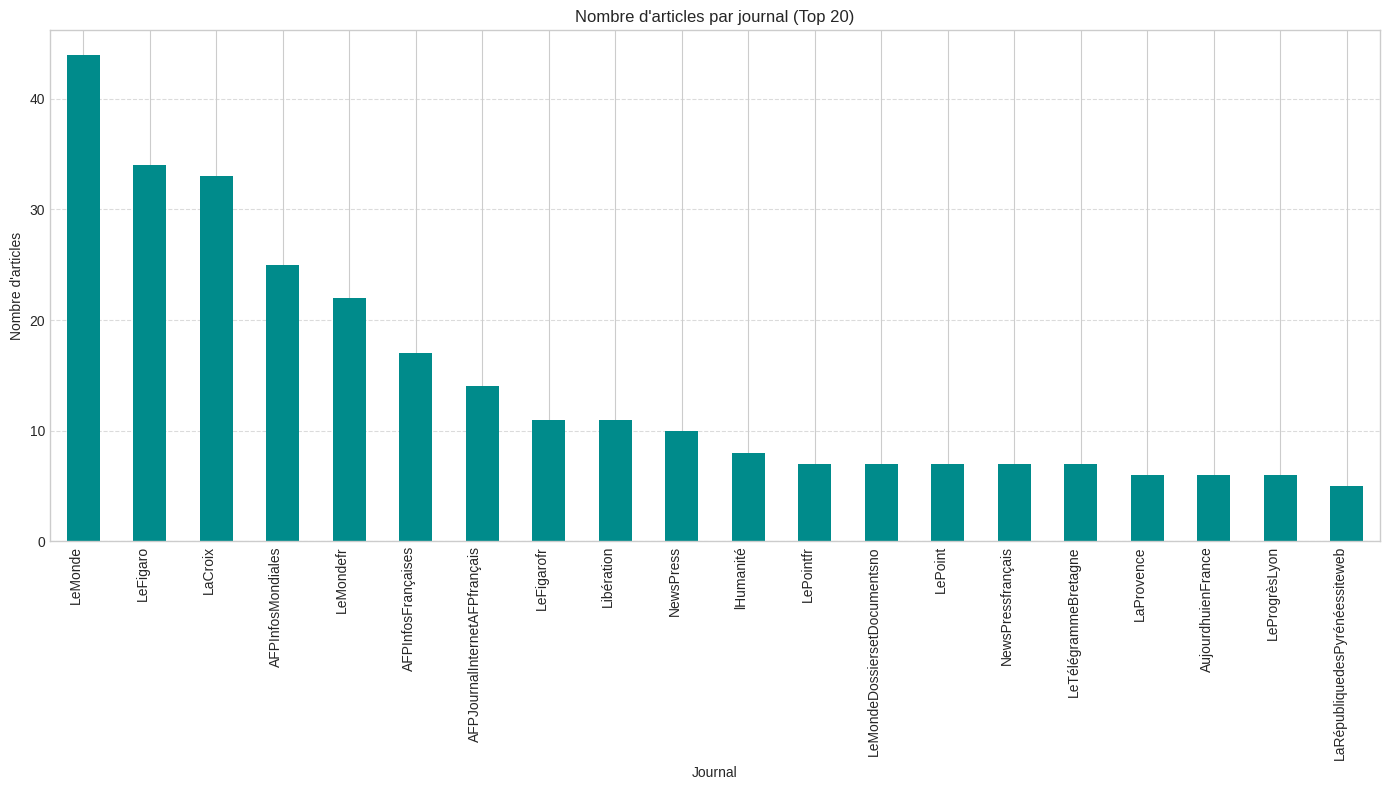

In [ ]:
import matplotlib.pyplot as plt

top_n_journals = articles_by_journal.head(20)

plt.figure(figsize=(14, 8))
top_n_journals.plot(kind='bar', color='darkcyan')
plt.title("Nombre d'articles par journal (Top 20)")
plt.xlabel('Journal')
plt.ylabel("Nombre d'articles")
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
df["word_count_desc"] = mots_par_article_desc

words_by_journal = df.groupby('journal')['word_count_desc'].sum().sort_values(ascending=False)

print("Nombre de mots par journal:")
print(words_by_journal.to_string())


Nombre de mots par journal:
journal
LeMonde                                                                                                                     50073
LeFigaro                                                                                                                    32179
LaCroix                                                                                                                     31075
LeMondefr                                                                                                                   23784
LExpress                                                                                                                    15808
Courrierinternational                                                                                                       15240
AFPInfosMondiales                                                                                                           14487
Libération                                            

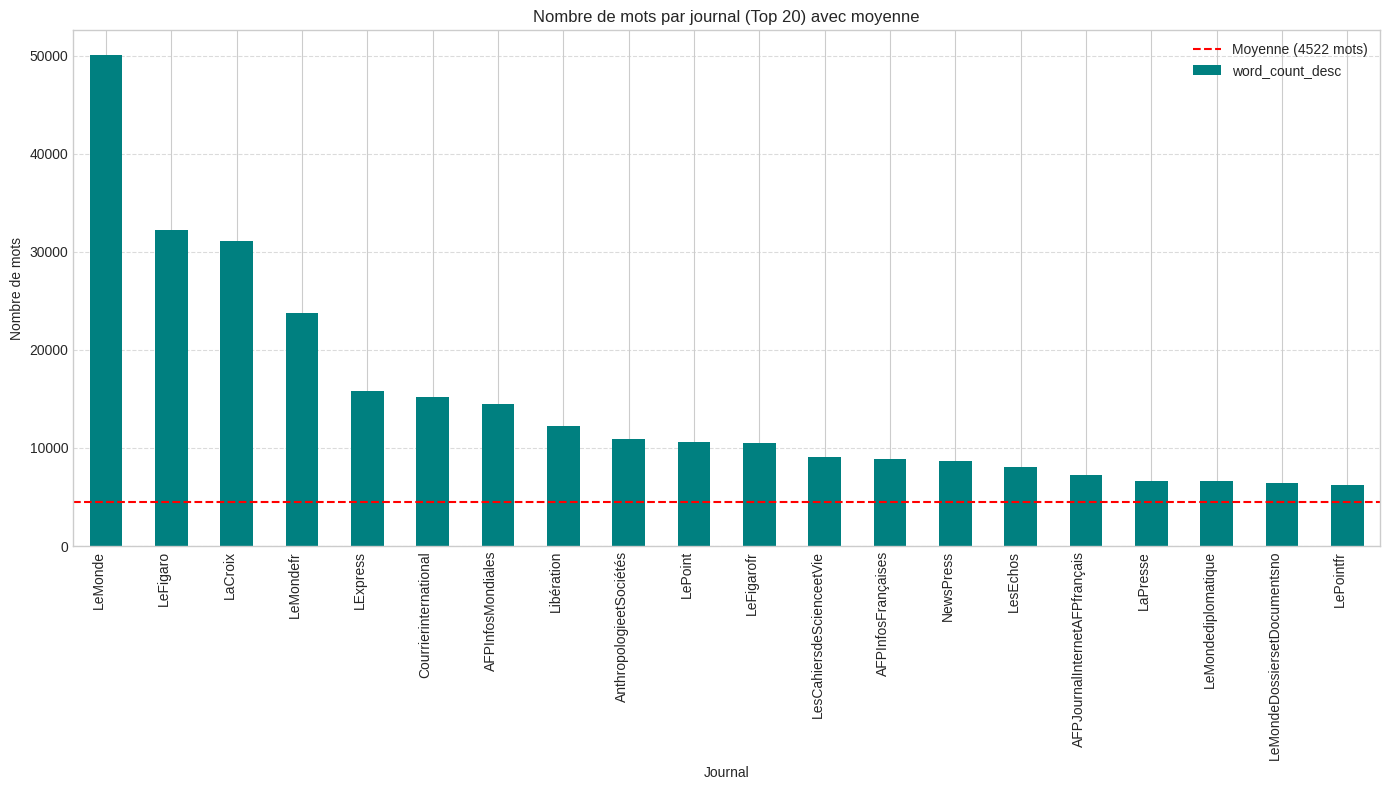

In [ ]:
import matplotlib.pyplot as plt

top_n_words_by_journal = words_by_journal.head(20)
average_words_per_journal = words_by_journal.mean()

plt.figure(figsize=(14, 8))
top_n_words_by_journal.plot(kind='bar', color='teal')
plt.axhline(y=average_words_per_journal, color='red', linestyle='--', label=f'Moyenne ({average_words_per_journal:.0f} mots)')

plt.title('Nombre de mots par journal (Top 20) avec moyenne')
plt.xlabel('Journal')
plt.ylabel('Nombre de mots')
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


## 7. Hypothèse de temporalité


In [ ]:
print(df.groupby('year_month').size().to_string())


year_month
1991-02     1
1994-09     1
1995-03     1
1996-07     1
1996-08     1
1996-10     1
1998-07     1
1998-08     1
1999-04     1
1999-08     1
2000-08     2
2000-12     1
2001-03     8
2001-04     2
2001-10     1
2001-12     1
2002-03     2
2002-04     1
2002-05     1
2002-07     6
2002-10     1
2002-11     5
2002-12     2
2003-03     6
2003-04     7
2003-05     1
2003-07    11
2003-08     1
2003-09     1
2003-10     1
2003-12    14
2004-01     6
2004-02     2
2004-03     1
2004-04     3
2004-05     2
2004-07     4
2004-08     1
2004-09     2
2004-12     4
2005-01     2
2005-04     1
2005-06     3
2005-07     1
2005-08     2
2005-09     3
2006-02     1
2006-03     1
2006-07     1
2006-09     1
2006-12     1
2007-06     5
2007-08     2
2007-09     1
2007-12     1
2008-02     1
2008-03     1
2008-06     4
2008-07     4
2009-05     1
2009-06     8
2009-07     1
2009-09     1
2010-02     2
2010-04     1
2010-05     1
2010-07     5
2010-08     9
2010-09     2
2011-02     2
2011-03  

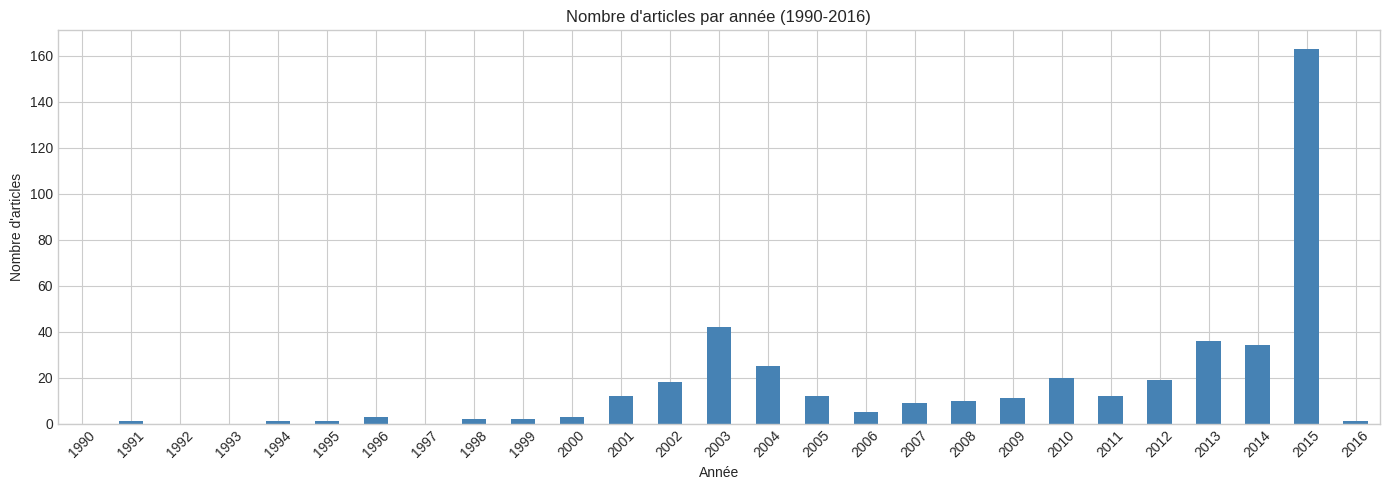

In [ ]:
import matplotlib.pyplot as plt

# Nombre d'articles par année (1990-2016) — déjà calculé en section 6 (articles_par_an)
articles_par_an.plot(kind='bar', figsize=(14, 5), color='steelblue')
plt.title("Nombre d'articles par année (1990-2016)")
plt.xlabel("Année")
plt.ylabel("Nombre d'articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


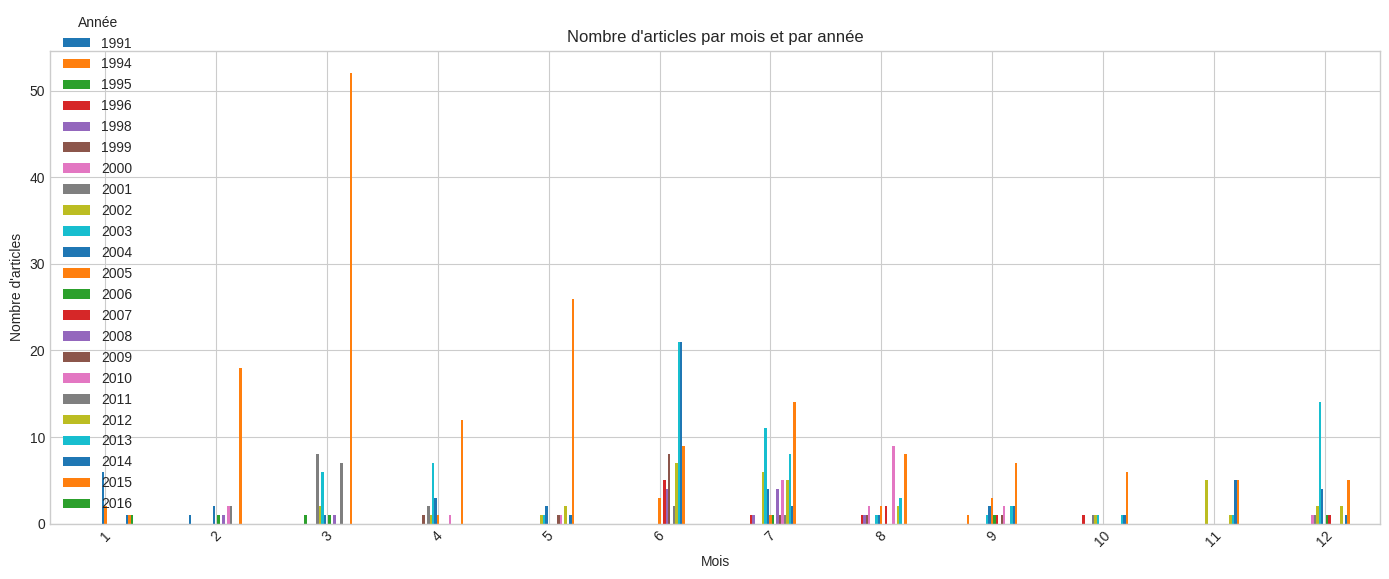

In [ ]:
# Par mois de chaque année
df['year'] = pd.to_datetime(df['date']).dt.year
df['month'] = pd.to_datetime(df['date']).dt.month
pivot = df.groupby(['year', 'month']).size().unstack(fill_value=0)

pivot.T.plot(kind='bar', figsize=(14, 6))
plt.title("Nombre d'articles par mois et par année")
plt.xlabel("Mois")
plt.ylabel("Nombre d'articles")
plt.xticks(rotation=45)
plt.legend(title='Année')
plt.tight_layout()
plt.show()


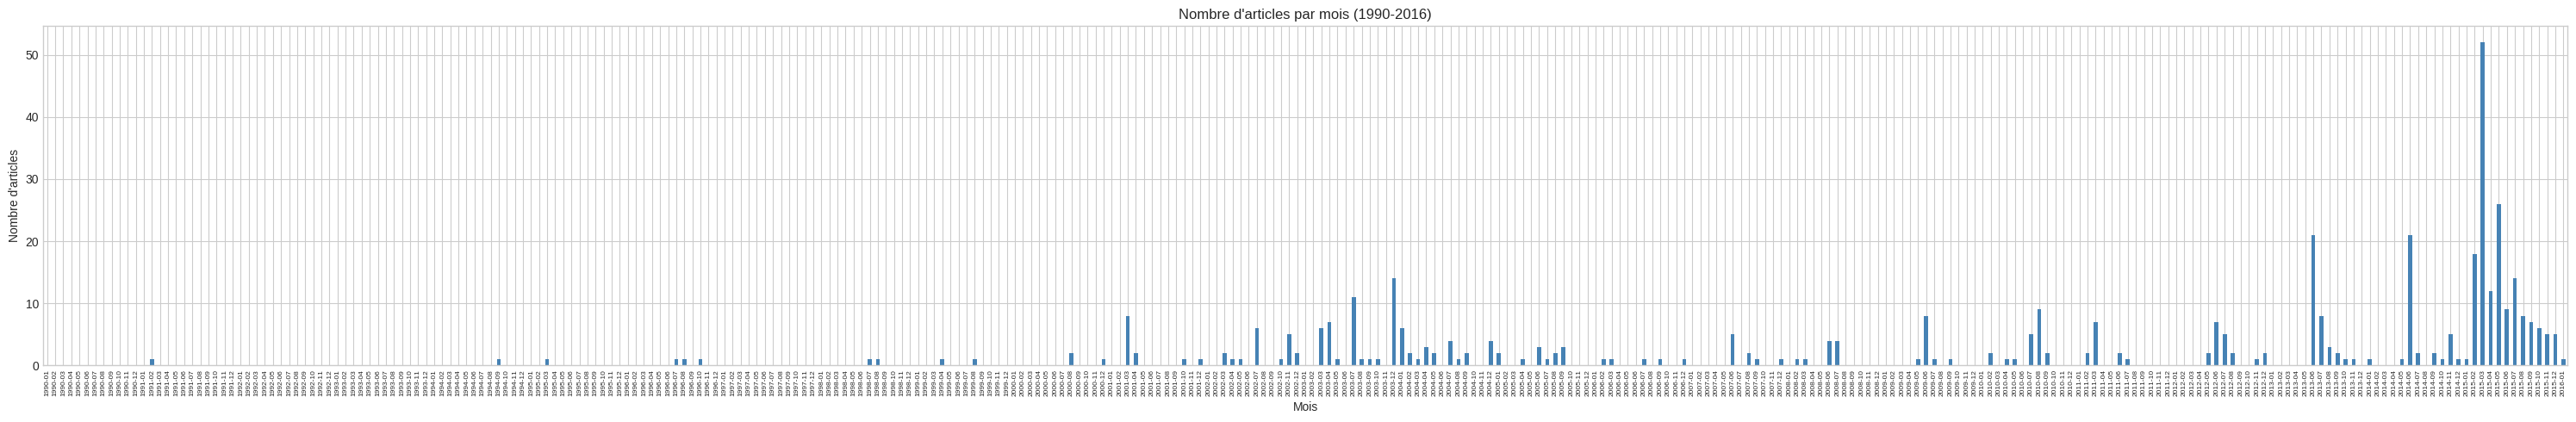

In [ ]:
df['year_month'] = pd.to_datetime(df['date']).dt.to_period('M')
articles_par_mois = df.groupby('year_month').size()

toutes_les_periodes = pd.period_range(start='1990-01', end='2016-01', freq='M')
articles_par_mois = articles_par_mois.reindex(toutes_les_periodes, fill_value=0)

articles_par_mois.plot(kind='bar', figsize=(30, 5), color='steelblue')
plt.title("Nombre d'articles par mois (1990-2016)")
plt.xlabel("Mois")
plt.ylabel("Nombre d'articles")
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()


## 8. Entités nommées




In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_pos = CountVectorizer(tokenizer=nothing, preprocessor=nothing, token_pattern=None)
X_pos = vectorizer_pos.fit_transform(df_lexical_view['pos'])

dtm_pos = pd.DataFrame(X_pos.toarray(), columns=vectorizer_pos.get_feature_names_out())
dtm_pos = dtm_pos.set_index(df_lexical_view['year'])

dtm_pos


KeyError: 'year'

In [ ]:
from lexploreur.description import *

dico_pos = features_frequencies(dtm_pos)

dico_pos


,freq
features,
NOUN,84603
ADP,71449
PUNCT,62172
DET,57997
VERB,36019
ADJ,29372
PRON,20195
ADV,16856
LOC,16706


### KWIC




In [ ]:
keywords_in_context("corpus_article_ner.json", pivot="LOC", field="pos")


,contexte_gauche,mot_pivot,contexte_droit
0,les trésors du musée de,Mossoul,( Irak ) en février
1,du musée de Mossoul (,Irak,) en février et nombre
2,se sont attaqués dimanche au,temple de Baalshamin,", l' un des plus"
3,de la cité antique de,Palmyre,"en Syrie , classée au"
4,cité antique de Palmyre en,Syrie,", classée au patrimoine mondial"
...,...,...,...
16701,"centre de l' Afghanistan ,",Bamiyan,"a été , durant le"
16702,l' antique route de la,Soie,", la vallée de Bamiyan a connu"
16703,"de la Soie , la",vallée de Bamiyan,a connu les conquêtes arabe
16704,poème sur les bouddhas de,Bamiyan,après un voyage dans ces


### Extraction des entités nommées


In [ ]:
def extract_ner(corpus_file, ner_tags, output="output_ner.csv"):
    """
    Extracts the named entitites detected in a corpus of documents made with lexploreur corpus() function.

    Parameters
    ----------
    corpus_file : str
        Path to the JSON file containing the corpus data.
    ner_tags : list or set
        List containing the NER labels to extract.
    output : str
        Name of the CSV file containing the NER data.

    Returns
    -------
    csv file
        A csv file containing the extracted named entitites.
    """

    with open(corpus_file, 'r', encoding='utf-8') as f:
        data = json.load(f)

    extracted = []

    for doc in data:
        doc_id = doc["document"]["id"]
        for feature in doc["document"]["lexical_features"]:
            if feature["pos"] in ner_tags:
                extracted.append({
                    "document_id": doc_id,
                    "type": feature["pos"],
                    "token": feature["token"]
                })

    df_extracted = pd.DataFrame(extracted)

    df_extracted.to_csv(output, index=False, encoding='utf-8')

    return (print(f"Extraction NERs terminée (fichier {output})."))


In [ ]:
ner_tags = {"PER", "MISC", "ORG", "LOC"}
extract_ner("corpus_article_ner.json", ner_tags, output="output_ner.csv")


Extraction NERs terminée (fichier output_ner.csv).


In [ ]:
ner_df = pd.read_csv("output_ner.csv")
loc_ner_df = ner_df[ner_df['type'] == 'LOC']

display(loc_ner_df.head())


,document_id,type,token
0,1,LOC,Mossoul
1,1,LOC,Irak
3,1,LOC,temple de Baalshamin
4,1,LOC,Palmyre
5,1,LOC,Syrie


In [ ]:
loc_ner_df.to_csv('loc_entities.csv', index=False)
print("Le fichier 'loc_entities.csv' a été créé.")


Le fichier 'loc_entities.csv' a été créé.


### Données générales du corpus


In [ ]:
df["word_count"] = df["content"].apply(lambda x: len(str(x).split()))

average_words = df["word_count"].mean()
total_words = df["content"].str.split().str.len().sum()

print(f"Moyenne de mots par article : {average_words:.1f}")
print(f"Nombre total de mots dans le corpus : {total_words}")


Moyenne de mots par article : 866.6
Nombre total de mots dans le corpus : 383059


## 9. Topic modeling — Corpus 1 (articles entiers)

*Méthode : Blei et al., 2003.*



In [ ]:
!pip install gensim

from gensim import corpora

dictionary_c1 = corpora.Dictionary(df_lexical_view_topic['lemma'])
gensim_corpus_c1 = [dictionary_c1.doc2bow(tokens) for tokens in df_lexical_view_topic['lemma']]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 69.4 MB/s eta 0:00:00


In [ ]:
from gensim.models import LdaModel

num_topics_c1 = 19
lda_model_c1 = LdaModel(gensim_corpus_c1, num_topics=num_topics_c1, id2word=dictionary_c1, passes=5, random_state=1826)

lda_model_c1.print_topics


<bound method BaseTopicModel.print_topics of <gensim.models.ldamodel.LdaModel object at 0x7ce1da9f7d70>>

In [ ]:
gamma_matrix_c1 = lda_model_c1.get_document_topics(gensim_corpus_c1, minimum_probability=0)
gamma_df_c1 = pd.DataFrame(gamma_matrix_c1, columns=[i for i in range(num_topics_c1)])
gamma_df_c1 = gamma_df_c1.fillna(0)

print(gamma_df_c1)

beta_matrix_c1 = lda_model_c1.get_topics()
beta_df_c1 = pd.DataFrame(beta_matrix_c1, columns=[dictionary_c1[i] for i in range(len(dictionary_c1))])

print(beta_df_c1)


                      0                   1                    2   \
0     (0, 0.00019580648)  (1, 0.00019580648)   (2, 0.00019580648)   
1     (0, 0.00016098218)  (1, 0.00016098218)   (2, 0.00016098218)   
2     (0, 9.5038115e-05)  (1, 9.5038115e-05)   (2, 9.5038115e-05)   
3     (0, 0.00016453108)  (1, 0.00016453108)   (2, 0.00016453108)   
4      (0, 0.0002301505)   (1, 0.0002301505)    (2, 0.0002301505)   
..                   ...                 ...                  ...   
437       (0, 0.8638159)  (1, 6.3248095e-05)     (2, 6.32481e-05)   
438   (0, 0.00038172086)  (1, 0.00038172086)   (2, 0.00038172086)   
439    (0, 9.521004e-05)   (1, 9.521004e-05)    (2, 9.521004e-05)   
440  (0, 0.000105639374)  (1, 0.00010563937)  (2, 0.000105639374)   
441      (0, 0.22379199)  (1, 0.00040208967)   (2, 0.00040208967)   

                      3                   4                    5   \
0     (3, 0.00019580648)   (4, 0.0001958065)   (5, 0.00019580648)   
1     (3, 0.00016098218)  (4, 0.0

In [ ]:
for topic_id in range(lda_model_c1.num_topics):
    print(f"Topic {topic_id} :")

    topic_words = lda_model_c1.get_topic_terms(topic_id, topn=10)
    for word_id, freq in topic_words:
        print(f"{dictionary_c1[word_id]}: {freq:.4f}")
    print("----")


In [ ]:
from lexploreur.tm import plot_tm

plot_tm(lda_model_c1, nwords=9, nrows=10, ncols=2)


## 10. Évaluation et optimisation du modèle LDA — Corpus 1



In [ ]:
lda_model_tuning_c1 = LdaModel(gensim_corpus_c1,
                  num_topics=10,
                  id2word=dictionary_c1,
                  random_state=1559)


In [ ]:
from gensim.models.coherencemodel import CoherenceModel

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

coherence_model = CoherenceModel(model=lda_model_tuning_c1,
                                     texts=df_lexical_view_topic['lemma'],
                                     dictionary=dictionary_c1,
                                     coherence='c_v')

coherence_model.get_coherence()


In [ ]:
topic_range_c1 = range(6, 21)
coherence_scores_c1 = []

for num_topics in topic_range_c1:
    lda_model_tuning_c1 = LdaModel(gensim_corpus_c1,
                         num_topics=num_topics,
                         id2word=dictionary_c1,
                         passes=10)

    coherence_model = CoherenceModel(model=lda_model_tuning_c1,
                                     texts=df_lexical_view_topic['lemma'],
                                     dictionary=dictionary_c1,
                                     coherence='c_v')

    coherence_score = coherence_model.get_coherence()
    coherence_scores_c1.append(coherence_score)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(topic_range_c1, coherence_scores_c1, marker='o')
plt.title('Scores de cohérence selon le nombre de topics (Corpus 1)')
plt.xlabel('Nombre de topics')
plt.ylabel('Métrique de cohérence')
plt.xticks(topic_range_c1)
plt.grid()
plt.show()


## 12. AFC (Analyse Factorielle des Correspondances)




In [ ]:
df_lexical_view_AFC = lexical_view('corpus_article_ner.json',
                               feature_to_extract="token",
                               stopwords=stopwords,
                               lowercase=True,
                               exclude_pos=["PUNCT", "SPACE", "SYM", "PROPN"],
                               group_by="year")


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_afc = CountVectorizer(tokenizer=nothing, preprocessor=nothing, token_pattern=None)
X_afc = vectorizer_afc.fit_transform(df_lexical_view_AFC['token'])

dtm_afc = pd.DataFrame(X_afc.toarray(), columns=vectorizer_afc.get_feature_names_out())
dtm_afc = dtm_afc.set_index(df_lexical_view_AFC['year'])

dtm_afc


In [ ]:
total_mots = dtm_afc.sum()
total_mots_tries = total_mots.sort_values(ascending=False)

top_300 = total_mots_tries.head(300).index
dtm_300 = dtm_afc[top_300]

table_lexicale = dtm_300.T

table_lexicale.to_csv("tle_corpus_presse.csv", index=True)
print("Table lexicale (top 300 mots x années) exportée vers 'tle_corpus_presse.csv'")
